In [7]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer
import shap
from itertools import product
import plotly.graph_objects as go
from minisom import MiniSom
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import OPTICS

# Dane przygotowane do trenowania modeli

In [8]:
data = pd.read_csv('data_after_prep.csv')

In [9]:
data.columns

Index(['emp_length', 'annual_income', 'dti', 'loan_amount', 'total_acc',
       'is_employed', 'date_diff', 'location_Northeast', 'location_South',
       'location_West', 'wealth_low', 'wealth_med', 'law_regulations_moderate',
       'law_regulations_restrictive', 'purpose_grouped_credit card',
       'purpose_grouped_other', 'verification_status_Source Verified',
       'verification_status_Verified', 'loan_status_Current',
       'loan_status_Fully Paid', 'home_ownership_NONE', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', '60_month_term'],
      dtype='object')

In [ ]:
means = data.mean(axis=0)
stds = data.std(axis=0)

print("Średnie cech:", means)
print("Odchylenia standardowe cech:", stds)

Średnia bliska 0, odchylenie standardowe bliskie 1 co zapewnia, że dane są wystandaryzowane.

In [10]:
X = data.select_dtypes(include=[float, int])

# Wizualizacje

## PCA

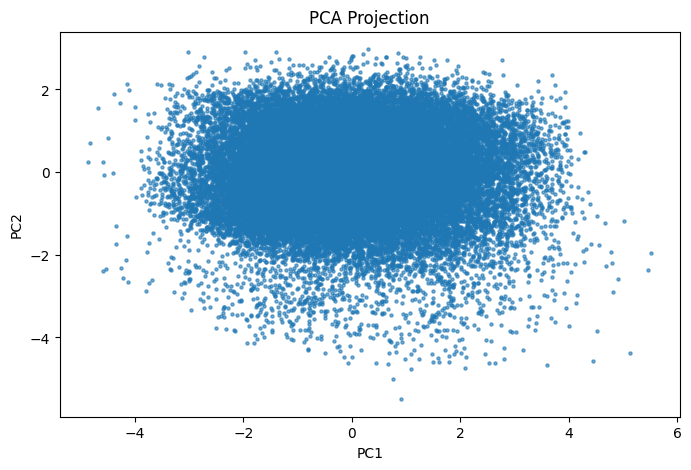

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.6)
plt.title('PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## TSNE

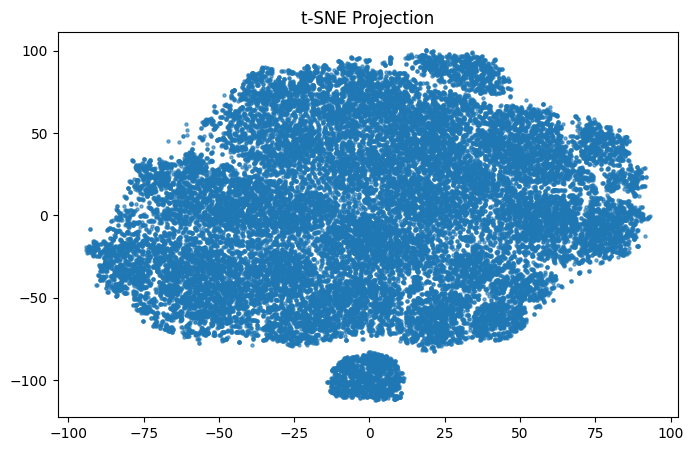

In [12]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=5, alpha=0.6)
plt.title('t-SNE Projection')
plt.show()

## UMAP

c:\Users\alapr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\alapr\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


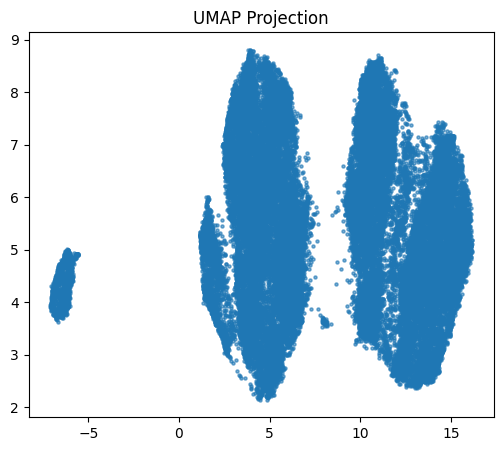

In [13]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)
plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], s=5, alpha=0.6)
plt.title('UMAP Projection')
plt.show()

# Redukowanie ilości zmiennych

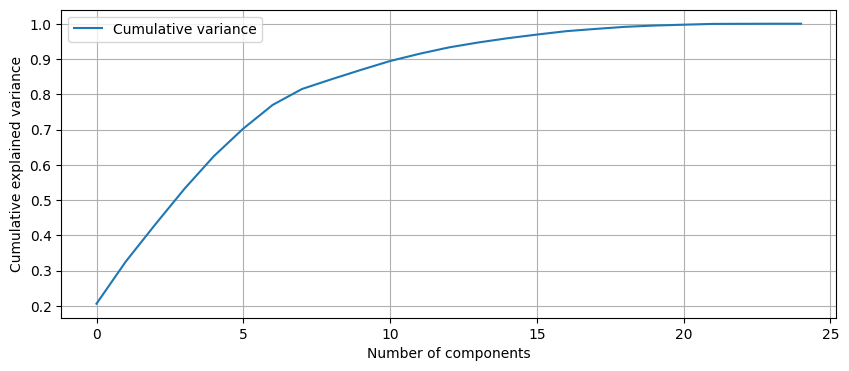

In [14]:
pca = PCA(n_components=X.shape[1], random_state=42)
pca.fit(X)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(cum_var, label='Cumulative variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.grid(True)
plt.show()

Ostatecznie decydujemy się na 10 komponentów zachowując 90% informacji.

In [15]:
X_pca = PCA(n_components=10, random_state=42).fit_transform(X)

# Parametry modeli

In [16]:
def model_eval(X, labels):
    unique_labels = set(labels)
    if len(unique_labels) < 2 or (len(unique_labels) == 1 and -1 in unique_labels):
        return {'silhouette': None, 'calinski': None, 'davies': None}
    
    silhouette = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    
    print(f'silhouette: {silhouette:.3f}, calinski: {calinski:.3f}, davies: {davies:.3f}')
    
    return {'silhouette': silhouette, 'calinski': calinski, 'davies': davies}

In [17]:
# --- KMeans Grid Search ---
def kmeans_grid_search(
    X,
    init_list=["k-means++", "random"],
    n_init_list=[10],
    algo_list=["lloyd", "elkan"],
    max_iter_list=[300],
    k_list=range(2, 8),
    scoring=["silhouette", "davies_bouldin_score"],
):
    results = []
    
    if "random" in init_list:
        n_init_list = list(set(n_init_list + [20]))

    for init, n_init, algo, max_iter, k, scoring_metric in product(
        init_list, n_init_list, algo_list, max_iter_list, k_list, scoring
    ):
        try:
            model = KMeans(
                n_clusters=k,
                init=init,
                n_init=n_init,
                algorithm=algo,
                max_iter=max_iter,
                random_state=42,
            )
            labels = model.fit_predict(X)
            
            if scoring_metric == "silhouette":
                score = silhouette_score(X, labels)
            elif scoring_metric == "davies_bouldin_score":
                score = -davies_bouldin_score(X, labels)  

            results.append({
                "params": f"k={k}, init={init}, n_init={n_init}, algo={algo}",
                "scoring": scoring_metric,
                "score": score,
            })
        except Exception as e:
            print(f"Błąd dla parametrów k={k}, init={init}, n_init={n_init}: {e}")
            continue

    result_df = pd.DataFrame(results)
    result_df["sort_key"] = result_df["score"] * np.where(result_df["scoring"] == "silhouette", 1, -1)
    return result_df.sort_values(by="sort_key", ascending=False).drop("sort_key", axis=1)

# --- Agglomerative Grid Search ---
def agglo_grid_search(X, linkage_list=["ward", "complete", "average", "single"], k_list=range(2, 8), scoring="silhouette"):
    results = []

    for linkage, k in product(linkage_list, k_list):
        try:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = model.fit_predict(X)
            score = silhouette_score(X, labels) if scoring == "silhouette" else None
            results.append({
                "model": "Agglomerative",
                "params": f"k={k}, linkage={linkage}",
                "score": score
            })
        except Exception:
            continue

    return pd.DataFrame(results).sort_values(by="score", ascending=False)

# --- GMM Grid Search ---
def gmm_grid_search(X, covariance_list=["full", "tied", "diag", "spherical"], k_list=range(2, 8), scoring="silhouette"):
    results = []

    for cov_type, k in product(covariance_list, k_list):
        try:
            model = GaussianMixture(n_components=k, covariance_type=cov_type, random_state=42)
            labels = model.fit(X).predict(X)
            score = silhouette_score(X, labels) if scoring == "silhouette" else None
            results.append({
                "model": "GMM",
                "params": f"k={k}, covariance={cov_type}",
                "score": score
            })
        except Exception:
            continue

    return pd.DataFrame(results).sort_values(by="score", ascending=False)

# --- DBSCAN Grid Search ---
def dbscan_grid_search(X, eps_list=[0.3, 0.5, 0.7, 1.0, 5.0], min_samples_list=[3, 5, 10], scoring="silhouette"):
    results = []

    for eps, min_s in product(eps_list, min_samples_list):
        try:
            model = DBSCAN(eps=eps, min_samples=min_s)
            labels = model.fit_predict(X)
            if len(set(labels)) <= 1 or len(set(labels)) >= len(X):  # skip noise-only or all-unique
                score = None
            else:
                score = silhouette_score(X, labels) if scoring == "silhouette" else None
            results.append({
                "model": "DBSCAN",
                "params": f"eps={eps}, min_samples={min_s}",
                "score": score
            })
        except Exception:
            continue

    return pd.DataFrame(results).sort_values(by="score", ascending=False)

# --- OPTICS Grid Search ---
def optics_grid_search(X, max_eps_list=[0.3, 0.5, 0.7, 1.0, 5.0], min_samples_list=[3, 5, 10], scoring="silhouette"):
    results = []

    for max_eps, min_s in product(max_eps_list, min_samples_list):
        try:
            model = OPTICS(max_eps=max_eps, min_samples=min_s)
            labels = model.fit_predict(X)
            # Skip if only noise or all unique clusters (noise as -1, clusters >=0)
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
            if n_clusters <= 1 or n_clusters >= len(X):
                score = None
            else:
                score = silhouette_score(X, labels) if scoring == "silhouette" else None
            results.append({
                "model": "OPTICS",
                "params": f"max_eps={max_eps}, min_samples={min_s}",
                "score": score
            })
        except Exception:
            continue

    return pd.DataFrame(results).sort_values(by="score", ascending=False)


## Grid search

In [18]:
#results_kmeans = kmeans_grid_search(X_pca)
#print(results_kmeans)
#results_kmeans.to_csv("results_kmeans.txt", index=False)

In [19]:
#results_agglo = agglo_grid_search(X_pca)
#print(results_agglo)
#results_agglo.to_csv("results_agglo.txt", index=False)

In [20]:
#results_gmm = gmm_grid_search(X_pca)
#print(results_gmm)
#results_gmm.to_csv("results_gmm.txt", index=False)

In [21]:
#results_dbscan = dbscan_grid_search(X_pca)
#print(results_dbscan)
#results_dbscan.to_csv("results_dbscan.txt", index=False)

In [22]:
#results_optics = optics_grid_search(X_pca)
#print(results_optics)
#results_optics.to_csv("results_optics.txt", index=False)

## Optymalna ilość klastrów

In [23]:
def find_optimal_clusters_multi_algorithm(X, algorithms=None, max_k=20):
    """
    Evaluate multiple clustering algorithms across different k values
    """
    
    if algorithms is None:
        algorithms = {
            'KMeans': KMeans,
            'AgglomerativeClustering': AgglomerativeClustering,
            'GaussianMixture': GaussianMixture
        }
    
    results = {}
    k_range = range(2, max_k + 1)
    
    print("Multi-Algorithm Cluster Evaluation:")
    print("=" * 60)
    
    for algo_name, algo_class in algorithms.items():
        print(f"\n{algo_name} Results:")
        print("-" * 40)
        
        silhouette_scores = []
        calinski_scores = []
        davies_scores = []
        inertias = []
        
        for k in k_range:
            print(f"\nK = {k}:")
            
            try:
                # Handle different algorithm parameter names
                if algo_name == 'GaussianMixture':
                    model = algo_class(n_components=k, random_state=42)
                    model.fit(X)
                    labels = model.predict(X)
                    inertia = None  # GMM doesn't have inertia
                elif algo_name == 'AgglomerativeClustering':
                    model = algo_class(n_clusters=k)
                    labels = model.fit_predict(X)
                    inertia = getattr(model, 'inertia_', None)
                else:
                    model = algo_class(n_clusters=k, random_state=42)
                    labels = model.fit_predict(X)
                    inertia = getattr(model, 'inertia_', None)
                
                # Evaluate clustering
                metrics = model_eval(X, labels)
                
                silhouette_scores.append(metrics['silhouette'])
                calinski_scores.append(metrics['calinski'])
                davies_scores.append(metrics['davies'])
                inertias.append(inertia)
                
            except Exception as e:
                print(f"Error with {algo_name} at k={k}: {e}")
                silhouette_scores.append(None)
                calinski_scores.append(None)
                davies_scores.append(None)
                inertias.append(None)
        
        # Store results
        results[algo_name] = {
            'silhouette_scores': silhouette_scores,
            'calinski_scores': calinski_scores,
            'davies_scores': davies_scores,
            'inertias': inertias
        }
    
    # Plot comparison
    plot_algorithm_comparison(results, k_range)
    
    # Find best k for each algorithm and metric
    print_best_k_summary(results, k_range)
    
    return results

def plot_algorithm_comparison(results, k_range):
    """Plot comparison of different algorithms across metrics"""
    
    algorithms = list(results.keys())
    n_algorithms = len(algorithms)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    metrics = ['silhouette_scores', 'calinski_scores', 'davies_scores', 'inertias']
    titles = ['Silhouette Score (Higher is Better)', 
              'Calinski-Harabasz Score (Higher is Better)',
              'Davies-Bouldin Score (Lower is Better)', 
              'Inertia/WCSS (Lower is Better)']
    
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[i]
        
        for j, algo in enumerate(algorithms):
            scores = results[algo][metric]
            # Filter out None values
            valid_k = [k for k, score in zip(k_range, scores) if score is not None]
            valid_scores = [score for score in scores if score is not None]
            
            if valid_scores:  # Only plot if we have valid scores
                ax.plot(valid_k, valid_scores, marker='o', 
                       label=algo, color=colors[j % len(colors)])
        
        ax.set_title(title)
        ax.set_xlabel('Number of clusters (k)')
        ax.set_ylabel(title.split('(')[0].strip())
        ax.legend()
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

def print_best_k_summary(results, k_range):
    """Print summary of best k for each algorithm and metric"""
    
    print(f"\n{'='*60}")
    print("BEST K SUMMARY")
    print(f"{'='*60}")
    
    for algo in results.keys():
        print(f"\n{algo}:")
        
        # Silhouette (higher is better)
        sil_scores = results[algo]['silhouette_scores']
        valid_sil = [(k, score) for k, score in zip(k_range, sil_scores) if score is not None]
        if valid_sil:
            best_k_sil = max(valid_sil, key=lambda x: x[1])
            print(f"  Best k (Silhouette): {best_k_sil[0]} (score: {best_k_sil[1]:.3f})")
        
        # Calinski-Harabasz (higher is better)
        cal_scores = results[algo]['calinski_scores']
        valid_cal = [(k, score) for k, score in zip(k_range, cal_scores) if score is not None]
        if valid_cal:
            best_k_cal = max(valid_cal, key=lambda x: x[1])
            print(f"  Best k (Calinski-Harabasz): {best_k_cal[0]} (score: {best_k_cal[1]:.3f})")
        
        # Davies-Bouldin (lower is better)
        dav_scores = results[algo]['davies_scores']
        valid_dav = [(k, score) for k, score in zip(k_range, dav_scores) if score is not None]
        if valid_dav:
            best_k_dav = min(valid_dav, key=lambda x: x[1])
            print(f"  Best k (Davies-Bouldin): {best_k_dav[0]} (score: {best_k_dav[1]:.3f})")


Multi-Algorithm Cluster Evaluation:

GaussianMixture Results:
----------------------------------------

K = 2:
silhouette: 0.439, calinski: 5286.341, davies: 1.028

K = 3:
silhouette: 0.043, calinski: 3193.756, davies: 4.338

K = 4:
silhouette: 0.119, calinski: 3308.024, davies: 2.139

K = 5:
silhouette: 0.068, calinski: 3882.793, davies: 2.497

K = 6:
silhouette: 0.053, calinski: 2468.691, davies: 3.709

K = 7:
silhouette: 0.015, calinski: 2412.423, davies: 3.021

K = 8:
silhouette: -0.007, calinski: 2018.709, davies: 3.910

K = 9:
silhouette: 0.012, calinski: 1810.558, davies: 4.211

K = 10:
silhouette: 0.031, calinski: 1926.323, davies: 3.701

K = 11:
silhouette: -0.001, calinski: 1748.631, davies: 4.357

K = 12:
silhouette: -0.046, calinski: 1527.076, davies: 3.022

K = 13:
silhouette: -0.059, calinski: 1498.376, davies: 2.862

K = 14:
silhouette: -0.033, calinski: 1328.209, davies: 4.394

K = 15:
silhouette: -0.043, calinski: 1261.321, davies: 4.354

K = 16:
silhouette: -0.058, ca

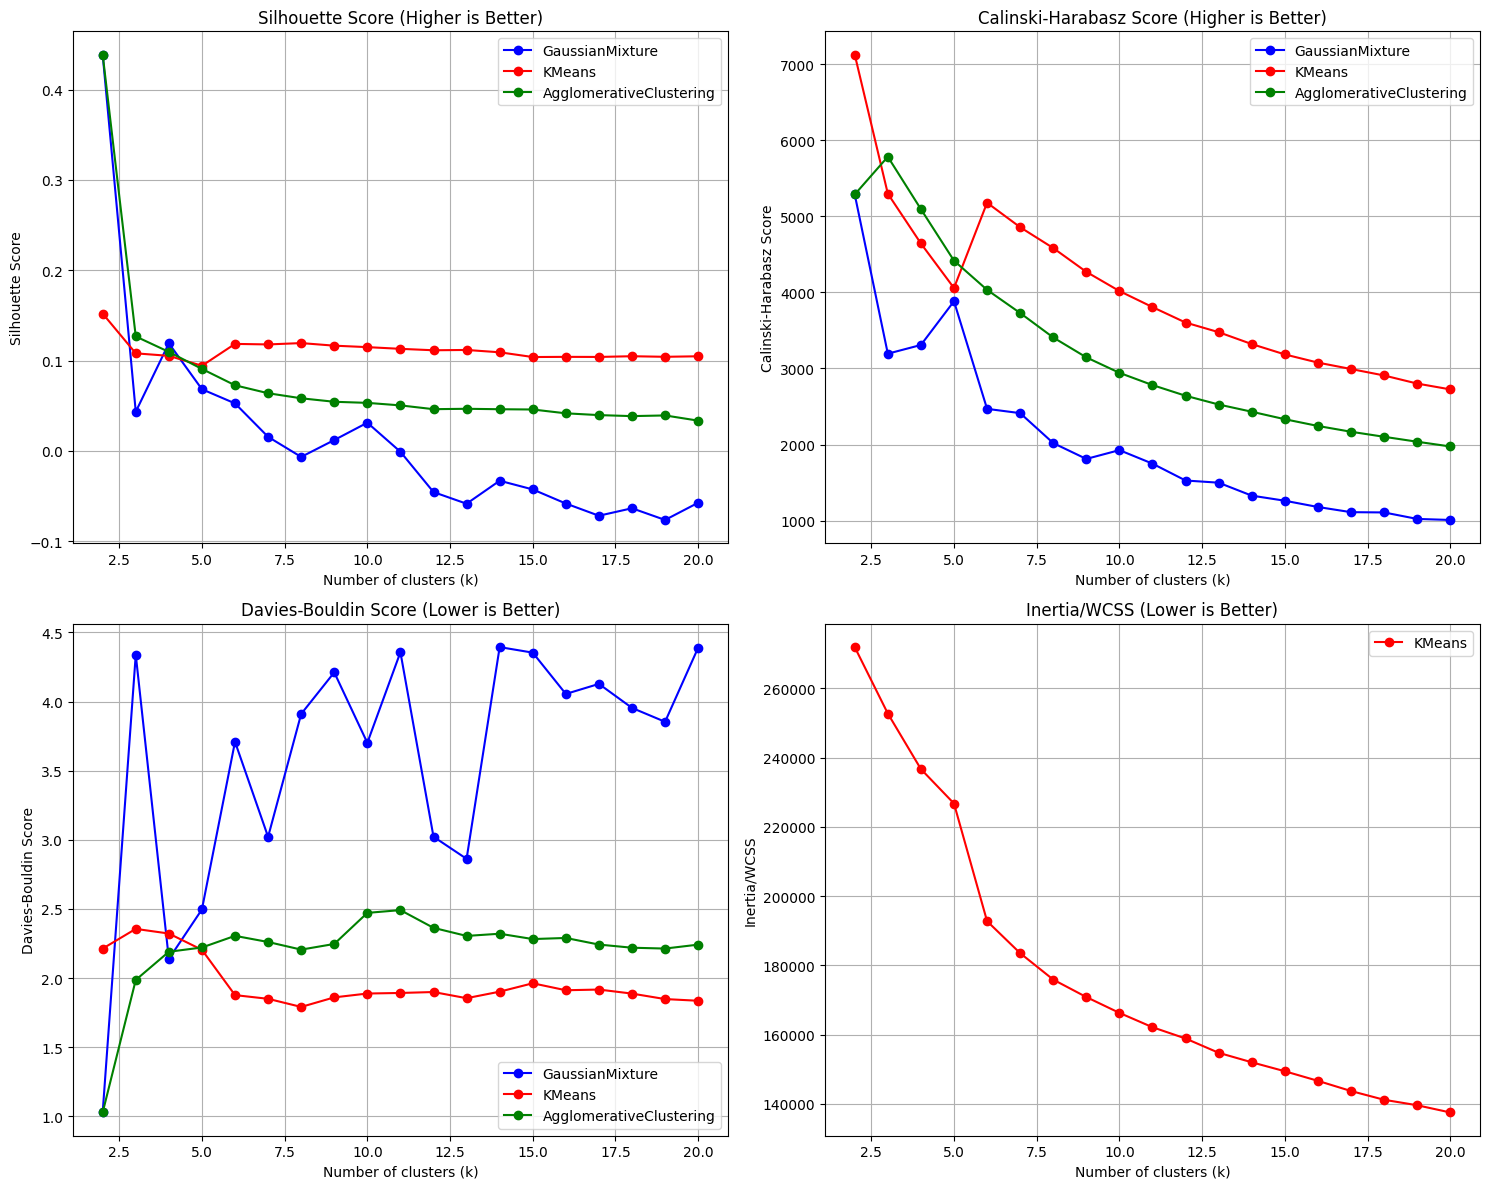


BEST K SUMMARY

GaussianMixture:
  Best k (Silhouette): 2 (score: 0.439)
  Best k (Calinski-Harabasz): 2 (score: 5286.341)
  Best k (Davies-Bouldin): 2 (score: 1.028)

KMeans:
  Best k (Silhouette): 2 (score: 0.152)
  Best k (Calinski-Harabasz): 2 (score: 7124.195)
  Best k (Davies-Bouldin): 8 (score: 1.791)

AgglomerativeClustering:
  Best k (Silhouette): 2 (score: 0.439)
  Best k (Calinski-Harabasz): 3 (score: 5781.698)
  Best k (Davies-Bouldin): 2 (score: 1.028)


In [24]:
algorithms = {  
        'GaussianMixture': GaussianMixture,
        'KMeans': KMeans,
        'AgglomerativeClustering': AgglomerativeClustering,
        }

results = find_optimal_clusters_multi_algorithm(X_pca, max_k=20, algorithms=algorithms)

# Modele i wizualizacje klasteryzacji

In [25]:
def plot_tsne_umap_clusters(X_tsne, X_umap, labels, title_tsne='t-SNE', title_umap='UMAP'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # t-SNE
    sc1 = axes[0].scatter(X_tsne[:,0], X_tsne[:,1], c=labels, s=5, alpha=0.6, cmap='Spectral')
    axes[0].set_title(title_tsne)
    plt.colorbar(sc1, ax=axes[0], label='Cluster Label')
    
    # UMAP
    sc2 = axes[1].scatter(X_umap[:,0], X_umap[:,1], c=labels, s=5, alpha=0.6, cmap='Spectral')
    axes[1].set_title(title_umap)
    plt.colorbar(sc2, ax=axes[1], label='Cluster Label')
    
    plt.tight_layout()
    plt.show()


In [26]:
labels_dict = {}

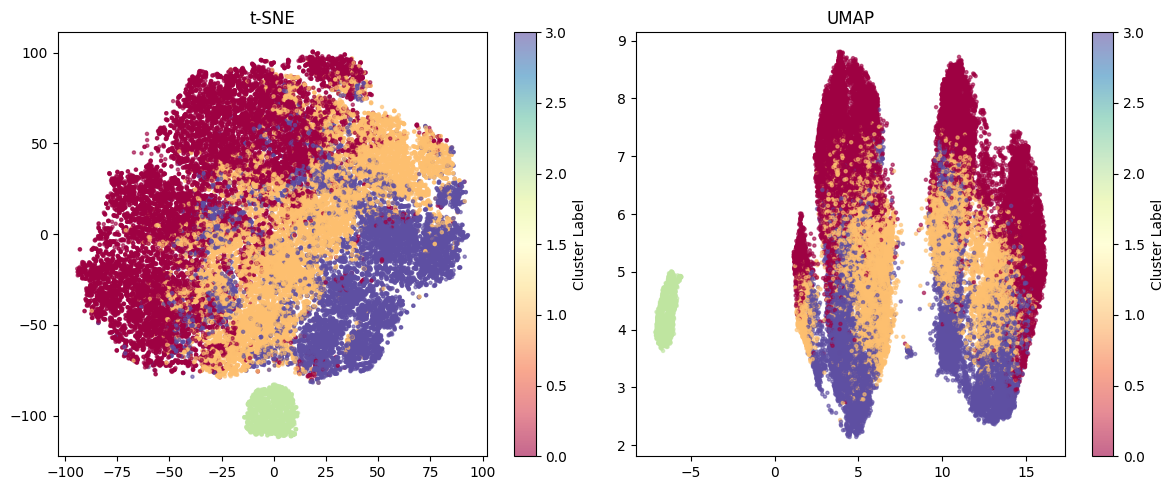

In [27]:
kmeans1 = KMeans(n_clusters=4, init = 'k-means++', n_init=10, algorithm= 'elkan', random_state=42).fit(X)
labels_kmeans1 = kmeans1.labels_
labels_dict['kmeans1'] = labels_kmeans1
plot_tsne_umap_clusters(X_tsne, X_umap, labels_kmeans1)

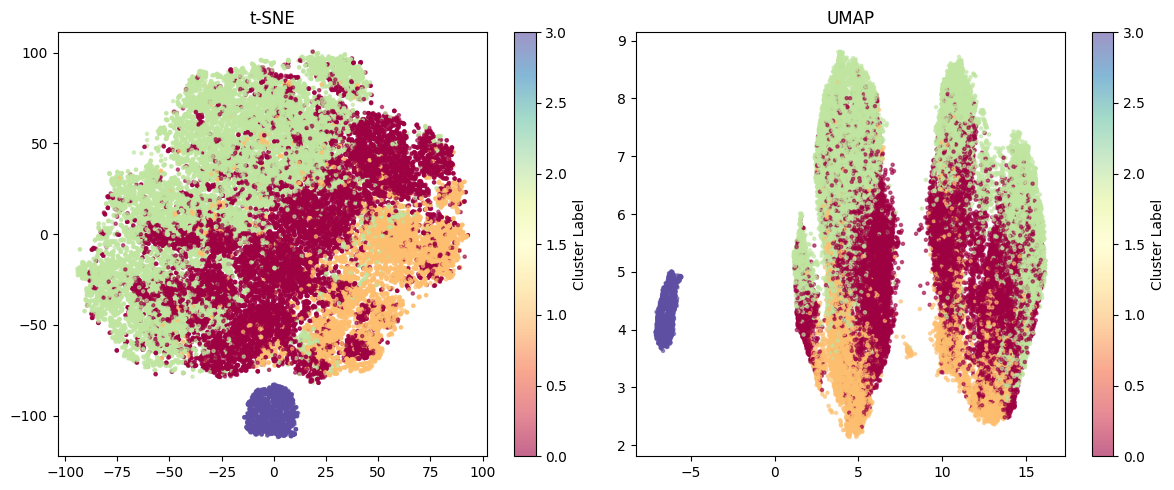

In [28]:
agglomerative2 = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(X)
labels_agglomerative2 = agglomerative2.labels_
labels_dict['agglomerative2'] = labels_agglomerative2
plot_tsne_umap_clusters(X_tsne, X_umap, labels_agglomerative2)

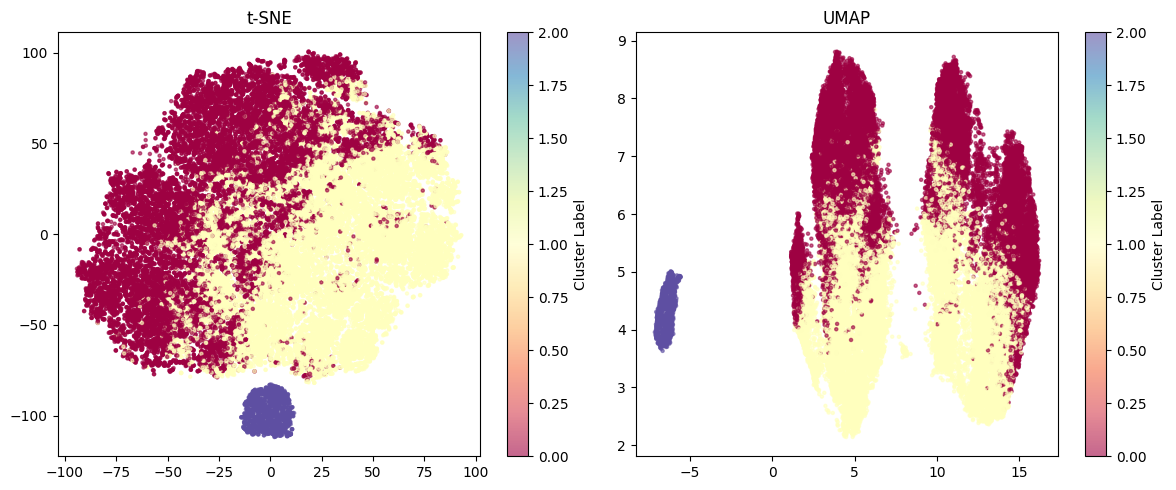

In [29]:
gaussian1 = GaussianMixture(n_components = 3, covariance_type='spherical', random_state=42).fit(X)
labels_gaussian1 = gaussian1.predict(X)
labels_dict['gaussian1'] = labels_gaussian1
plot_tsne_umap_clusters(X_tsne, X_umap, labels_gaussian1)

# Interpretowalność

In [30]:
def cpu_cluster_interpret(X, labels_dict, n_samples=5000, random_state=42):
    """
    CPU-based clustering interpretability analysis using SHAP
    
    Parameters:
        X (pd.DataFrame/np.ndarray): Input features
        labels_dict (dict): Dictionary of {model_name: cluster_labels}
        n_samples (int): Number of samples for SHAP analysis
        random_state (int): Reproducibility seed
    
    Returns:
        dict: SHAP values and feature importances for each clustering
    """
    # Convert to pandas DataFrame if not already
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    
    results = {}
    
    for name, labels in labels_dict.items():
        # Encode labels if needed
        le = LabelEncoder()
        encoded_labels = le.fit_transform(labels)
        
        # Subsample data
        if len(X) > n_samples:
            sample_idx = np.random.choice(len(X), n_samples, replace=False)
            X_sample = X.iloc[sample_idx]
            labels_sample = encoded_labels[sample_idx]
        else:
            X_sample = X
            labels_sample = encoded_labels
        
        # Train CPU RandomForest
        clf = RandomForestClassifier(n_estimators=100, 
                                   random_state=random_state,
                                   n_jobs=-1)  # Use all CPU cores
        clf.fit(X_sample, labels_sample)
        
        # Calculate SHAP values
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_sample)
        
        # Calculate feature importance
        if isinstance(shap_values, list):
            feature_importance = np.mean([np.abs(v).mean(0) for v in shap_values], 0)
        else:
            feature_importance = np.abs(shap_values).mean(0)
        
        results[name] = {
            'shap_values': shap_values,
            'feature_importance': feature_importance,
            'features': X.columns.tolist()
        }
    
    return results


In [31]:
def plot_feature_importance(results):
    for model_name, data in results.items():
        features = data['features']
        importance = np.array(data['feature_importance']).flatten()
        
        # Ensure lengths match
        min_len = min(len(features), len(importance))
        features = features[:min_len]
        importance = importance[:min_len]
        
        # Sort features by importance (descending)
        sorted_idx = importance.argsort()[::-1]
        sorted_features = [features[i] for i in sorted_idx]
        sorted_importance = importance[sorted_idx]
        
        plt.figure(figsize=(10, 6))
        plt.barh(sorted_features, sorted_importance, color='skyblue')
        plt.xlabel('Mean Absolute SHAP Value')
        plt.title(f'Feature Importance for {model_name}')
        plt.gca().invert_yaxis()  # Highest importance on top
        plt.tight_layout()
        plt.show()

In [32]:
results1 = cpu_cluster_interpret(X, labels_dict, n_samples=2000, random_state=42)

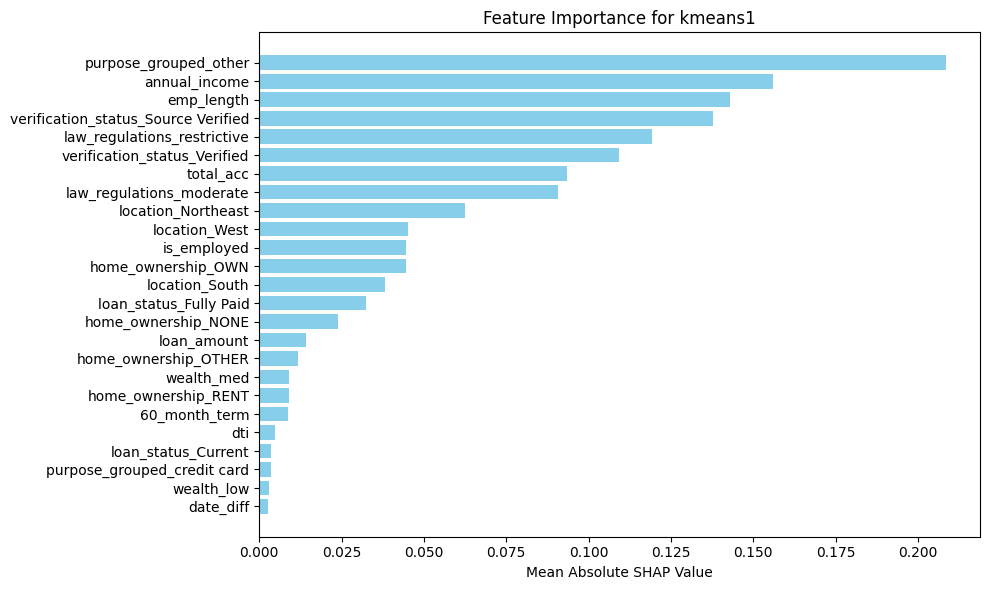

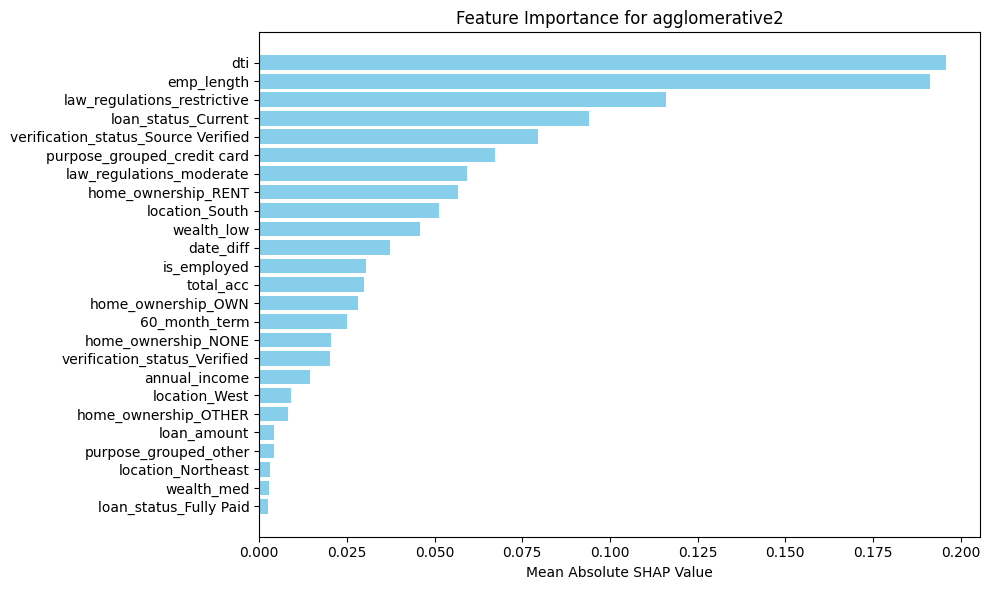

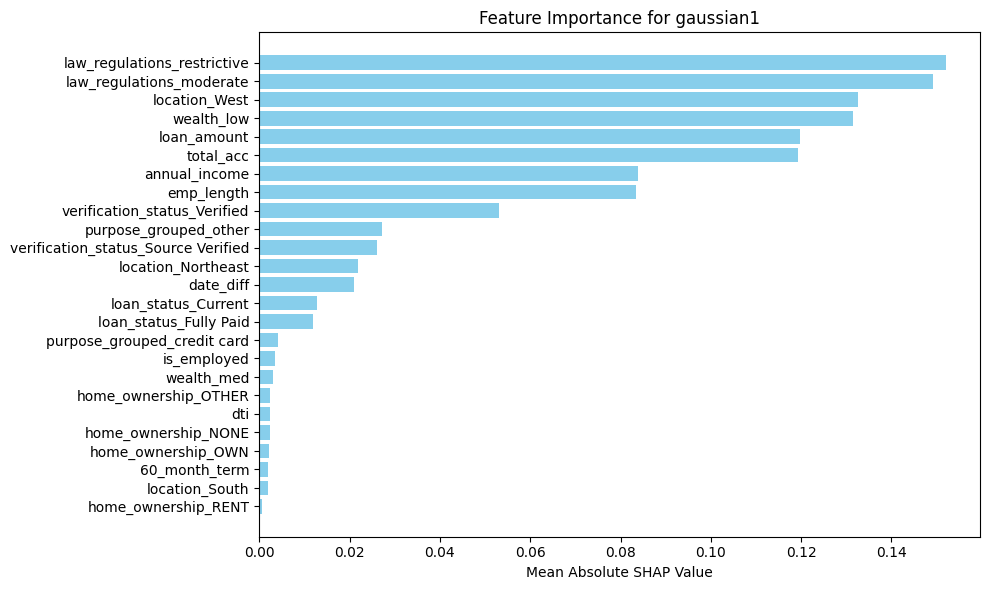

In [33]:
plot_feature_importance(results1)

# Analiza wrażliwości cech dla różnych klastrów

In [35]:
data['cluster'] = labels_dict['gaussian1']

In [36]:
def sensitivity_analysis(model, data, cluster_col='cluster', n_samples=2, epsilon=0.1):
    """
    Dla każdego klastra wybiera n_samples rekordów i wykonuje analizę wrażliwości cech
    (sensitivity analysis) dla każdego z nich, tworząc osobny wykres.
    
    Parametry:
    - model: wytrenowany model klasteryzujący (np. GaussianMixture, KMeans)
    - data: DataFrame zawierający dane i kolumnę z etykietami klastrów
    - cluster_col: nazwa kolumny z etykietami klastrów
    - n_samples: liczba rekordów do pobrania z każdego klastra (domyślnie 2)
    - epsilon: wielkość perturbacji cechy (domyślnie 0.1)
    """
    feature_names = [col for col in data.columns if col != cluster_col]
    selected_indices = []
    for cluster_id in data[cluster_col].unique():
        cluster_data = data[data[cluster_col] == cluster_id]
        if len(cluster_data) >= n_samples:
            sampled = cluster_data.sample(n=n_samples, random_state=42)
            selected_indices.extend(sampled.index.tolist())
        else:
            selected_indices.extend(cluster_data.index.tolist())
    
    for idx in selected_indices:
        record = data.loc[idx, feature_names].values
        probs = model.predict_proba(record.reshape(1, -1))[0]
        assigned_cluster = np.argmax(probs)
        sensitivity = []
        for i in range(len(record)):
            perturbed = record.copy()
            perturbed[i] += epsilon * np.std(model.means_[:, i])
            perturbed_probs = model.predict_proba(perturbed.reshape(1, -1))[0]
            delta = np.abs(perturbed_probs[assigned_cluster] - probs[assigned_cluster])
            sensitivity.append(delta)
        sensitivity = np.array(sensitivity)
        sensitivity_norm = sensitivity / sensitivity.sum() if sensitivity.sum() > 0 else sensitivity
        plt.figure(figsize=(10, 6))
        plt.bar(feature_names, sensitivity_norm, color='salmon')
        plt.title(f'Record {idx} (orig cluster: {data.loc[idx, cluster_col]}) - Assigned: {assigned_cluster}')
        plt.xlabel('Feature')
        plt.ylabel('Normalized Sensitivity')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print(f"Record {idx}: Assigned cluster {assigned_cluster}, Original cluster: {data.loc[idx, cluster_col]}")
        print(f"Cluster probabilities: {probs}\n{'-'*60}")


In [ ]:
import warnings
warnings.filterwarnings("ignore")

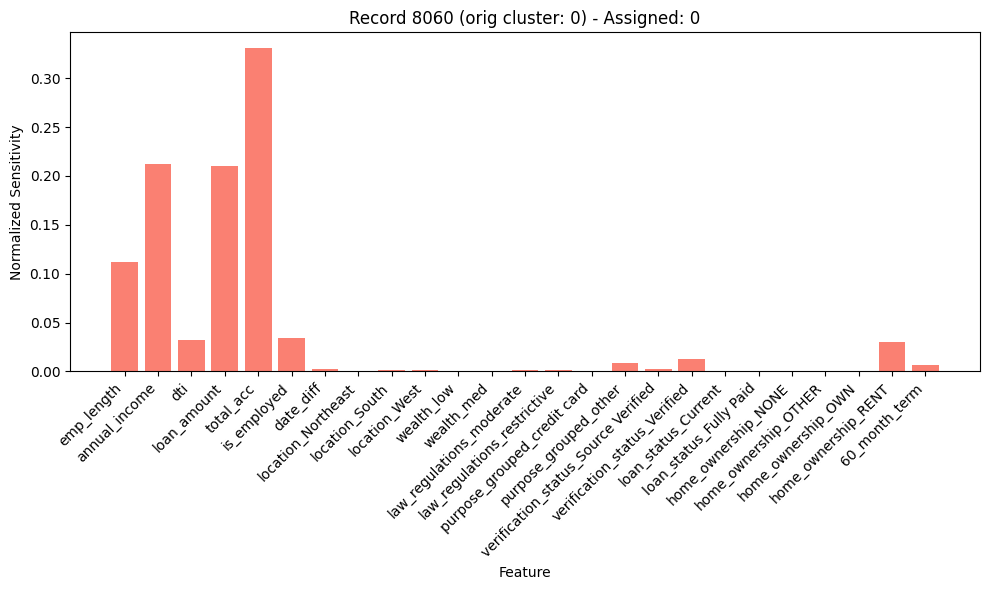

Record 8060: Assigned cluster 0, Original cluster: 0
Cluster probabilities: [9.98710773e-01 1.28922656e-03 4.63701490e-19]
------------------------------------------------------------


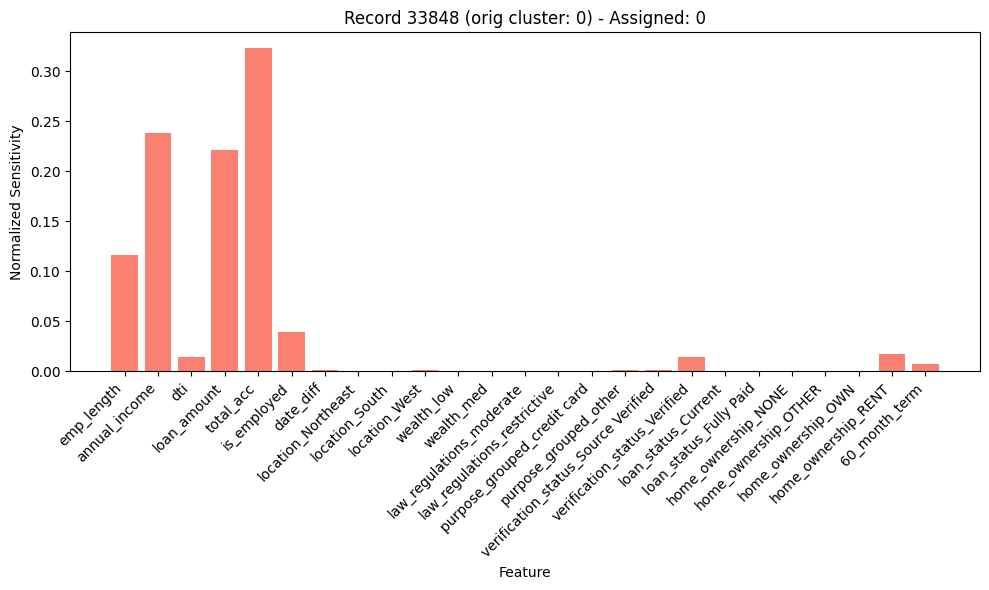

Record 33848: Assigned cluster 0, Original cluster: 0
Cluster probabilities: [9.99999699e-01 3.01088290e-07 4.44988298e-20]
------------------------------------------------------------


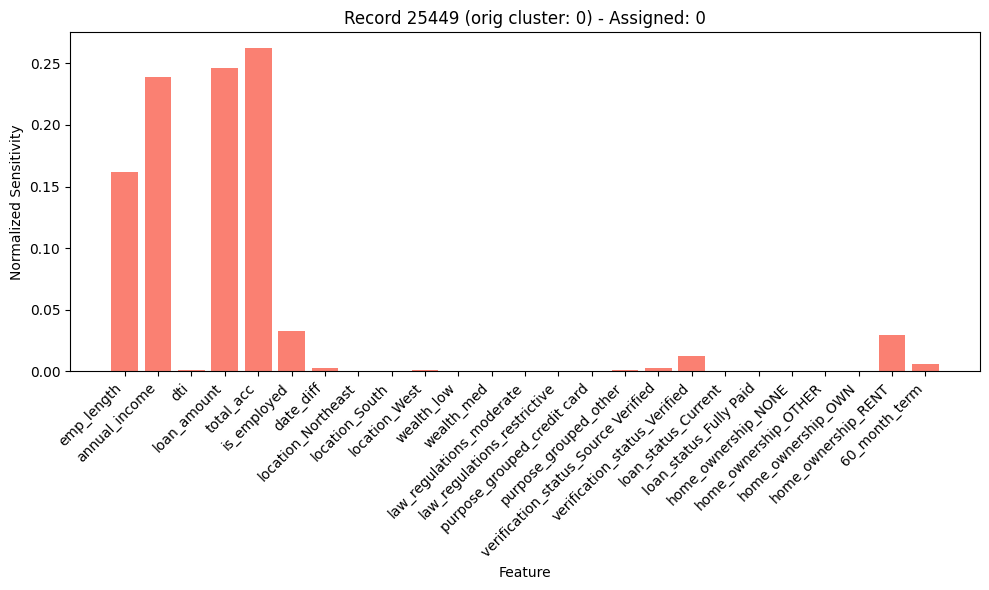

Record 25449: Assigned cluster 0, Original cluster: 0
Cluster probabilities: [9.20166361e-01 7.98336389e-02 2.60078804e-17]
------------------------------------------------------------


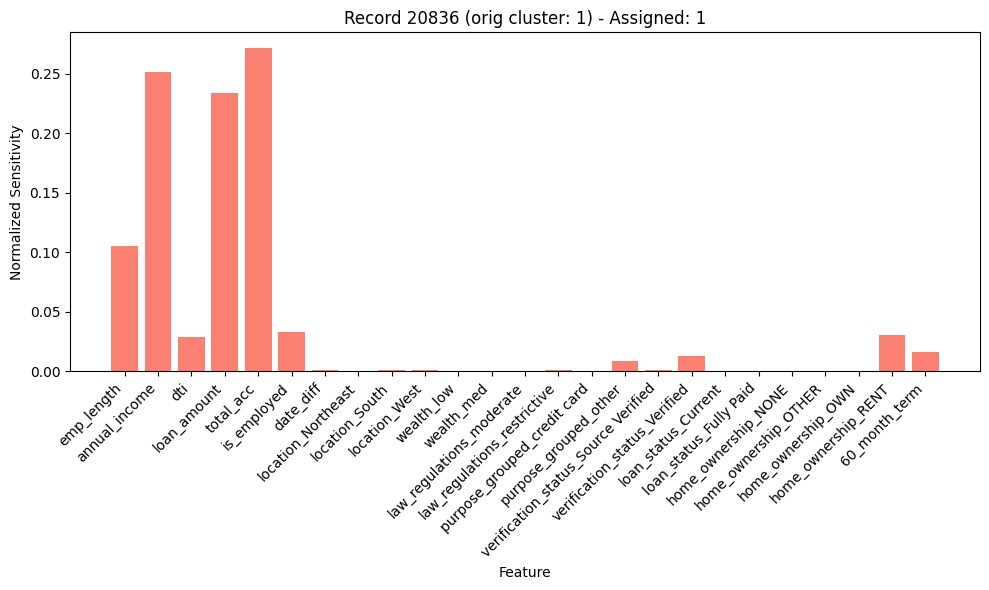

Record 20836: Assigned cluster 1, Original cluster: 1
Cluster probabilities: [4.93674918e-01 5.06325082e-01 1.60074773e-17]
------------------------------------------------------------


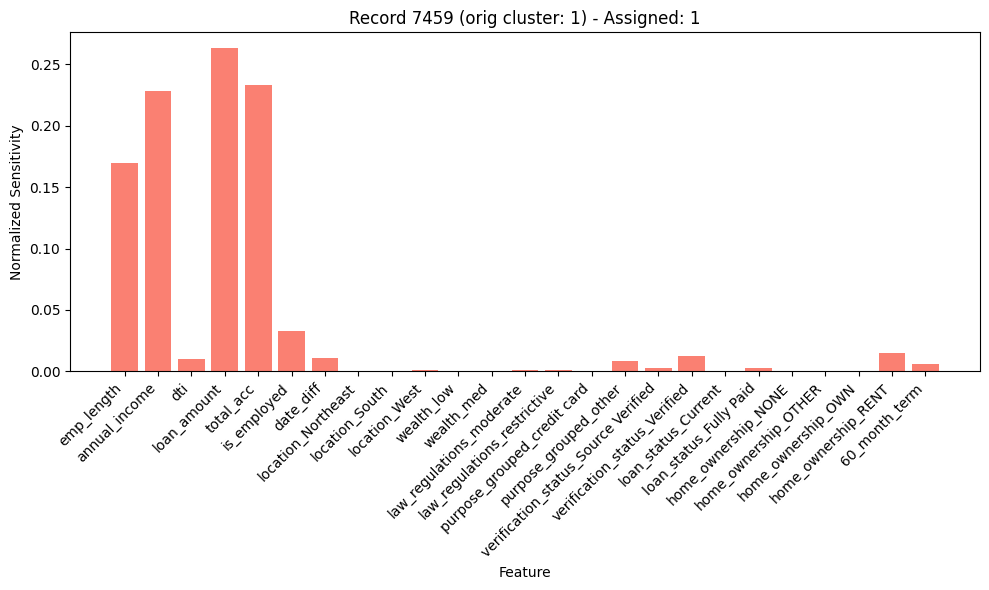

Record 7459: Assigned cluster 1, Original cluster: 1
Cluster probabilities: [7.11893741e-04 9.99288106e-01 3.68763043e-18]
------------------------------------------------------------


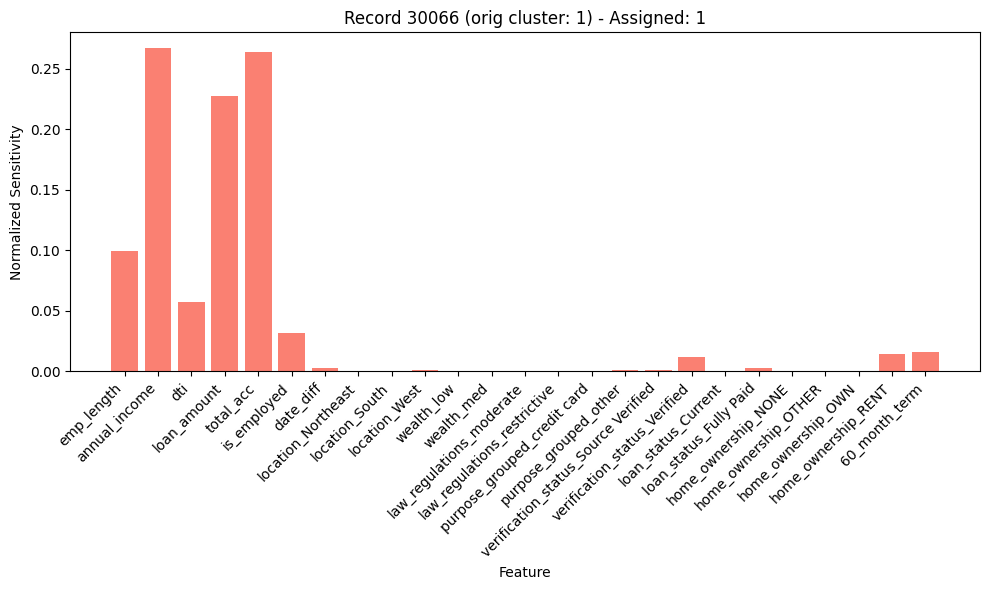

Record 30066: Assigned cluster 1, Original cluster: 1
Cluster probabilities: [2.66863381e-05 9.99973314e-01 1.76569581e-18]
------------------------------------------------------------


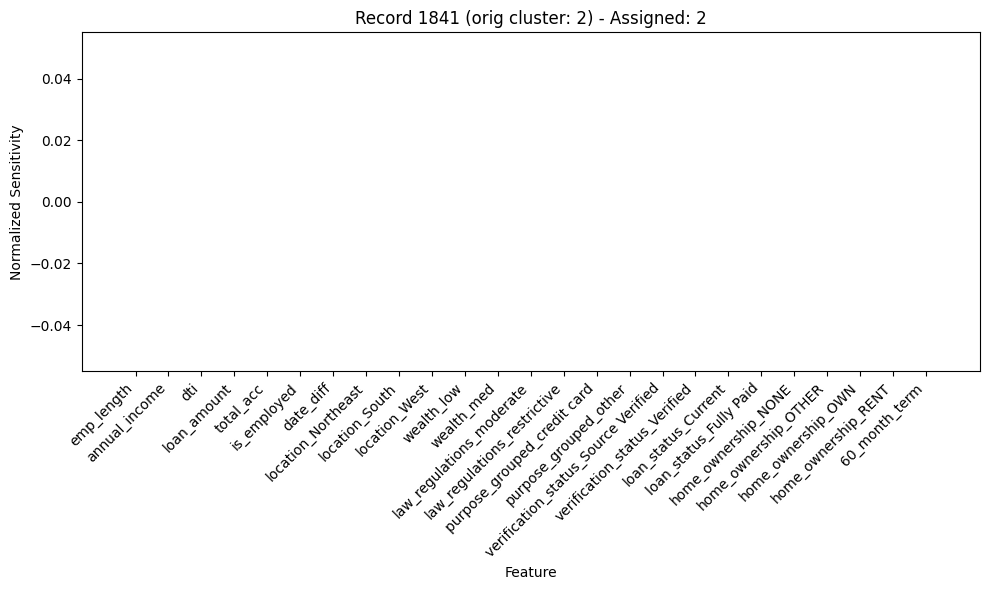

Record 1841: Assigned cluster 2, Original cluster: 2
Cluster probabilities: [3.83544008e-22 1.76568656e-20 1.00000000e+00]
------------------------------------------------------------


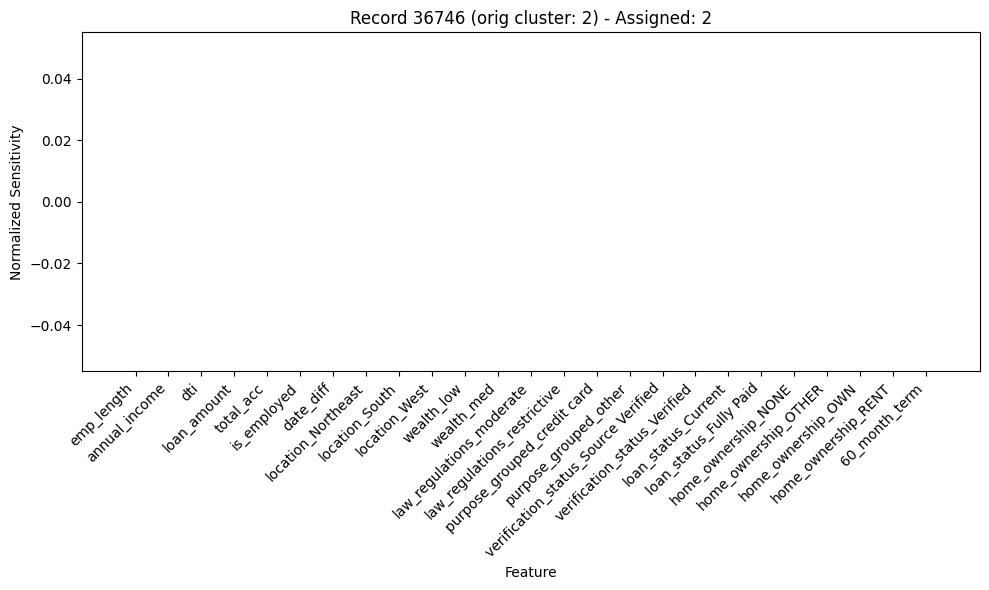

Record 36746: Assigned cluster 2, Original cluster: 2
Cluster probabilities: [3.49960601e-21 2.73445973e-20 1.00000000e+00]
------------------------------------------------------------


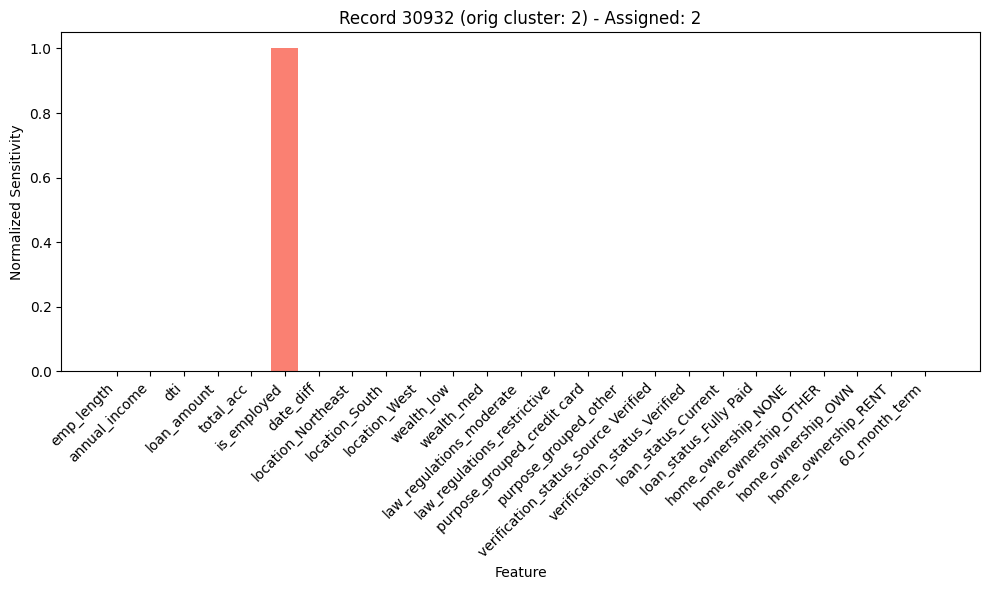

Record 30932: Assigned cluster 2, Original cluster: 2
Cluster probabilities: [9.50546801e-26 5.97233565e-17 1.00000000e+00]
------------------------------------------------------------


In [40]:
sensitivity_analysis(gaussian1, data, cluster_col='cluster', n_samples=3)

In [45]:
cluster0 = data[data['cluster'] == 0]
cluster1 = data[data['cluster'] == 1]
cluster2 = data[data['cluster'] == 2]
clusters =[cluster0, cluster1, cluster2]

In [46]:
for i, cluster in enumerate(clusters):
    count = cluster.shape[0]
    print(f"Cluster {i}: {count}")

Cluster 0: 18605
Cluster 1: 18533
Cluster 2: 1438


Ostatni klaster zawiera osoby, które nie są zatrudnione.

In [50]:
for i, cluster in enumerate(clusters):
    count = cluster[cluster['is_employed'] > 0].shape[0]
    print(f"Cluster {i}: {count}")

Cluster 0: 18605
Cluster 1: 18533
Cluster 2: 0
